In [3]:
import pandas as pd

df = pd.read_csv('/content/Dataset_processed_for_ANN.csv')

In [4]:
display(df.head())

,SeniorCitizen,tenure,MonthlyCharges,IsNewCustomer,gender,Dependents,PhoneService,MultipleLines,InternetService,Contract_Month-to-month,Contract_One year,Contract_Two year,Churn
0,0.0,0.013889,0.069307,0.0,0,0,0,0,0,True,False,False,1
1,0.0,0.569444,0.069307,0.0,1,0,1,0,0,False,True,False,0
2,0.0,0.722222,0.009901,0.0,0,1,1,0,0,True,False,False,0
3,0.0,0.013889,0.574257,0.0,0,0,1,0,0,False,True,False,1
4,0.0,0.930556,0.326733,0.0,1,0,1,0,1,True,False,False,0


## Preparing Data for Clustering




In [5]:
X = df.copy()
display(X.head())

,SeniorCitizen,tenure,MonthlyCharges,IsNewCustomer,gender,Dependents,PhoneService,MultipleLines,InternetService,Contract_Month-to-month,Contract_One year,Contract_Two year,Churn
0,0.0,0.013889,0.069307,0.0,0,0,0,0,0,True,False,False,1
1,0.0,0.569444,0.069307,0.0,1,0,1,0,0,False,True,False,0
2,0.0,0.722222,0.009901,0.0,0,1,1,0,0,True,False,False,0
3,0.0,0.013889,0.574257,0.0,0,0,1,0,0,False,True,False,1
4,0.0,0.930556,0.326733,0.0,1,0,1,0,1,True,False,False,0


## Determine Optimal Number of Clusters




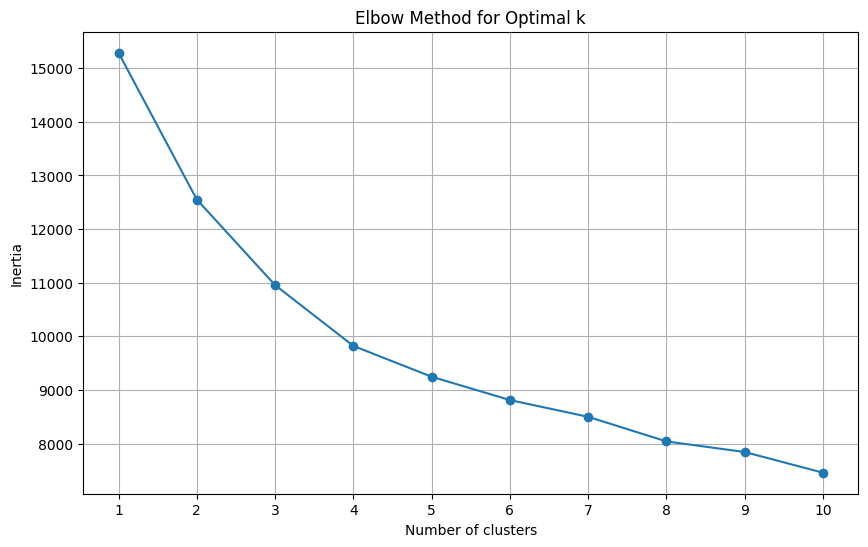

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for i in range(1, 11): # Looping from 1 to 10 clusters
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


## Applying K-Means Clustering





In [7]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans.fit(X)
X['Cluster'] = kmeans.labels_
print(f"K-Means clustering completed with {k_optimal} clusters.")
display(X.head())

K-Means clustering completed with 4 clusters.


,SeniorCitizen,tenure,MonthlyCharges,IsNewCustomer,gender,Dependents,PhoneService,MultipleLines,InternetService,Contract_Month-to-month,Contract_One year,Contract_Two year,Churn,Cluster
0,0.0,0.013889,0.069307,0.0,0,0,0,0,0,True,False,False,1,3
1,0.0,0.569444,0.069307,0.0,1,0,1,0,0,False,True,False,0,2
2,0.0,0.722222,0.009901,0.0,0,1,1,0,0,True,False,False,0,3
3,0.0,0.013889,0.574257,0.0,0,0,1,0,0,False,True,False,1,2
4,0.0,0.930556,0.326733,0.0,1,0,1,0,1,True,False,False,0,1


## Visualization of Customer Segments




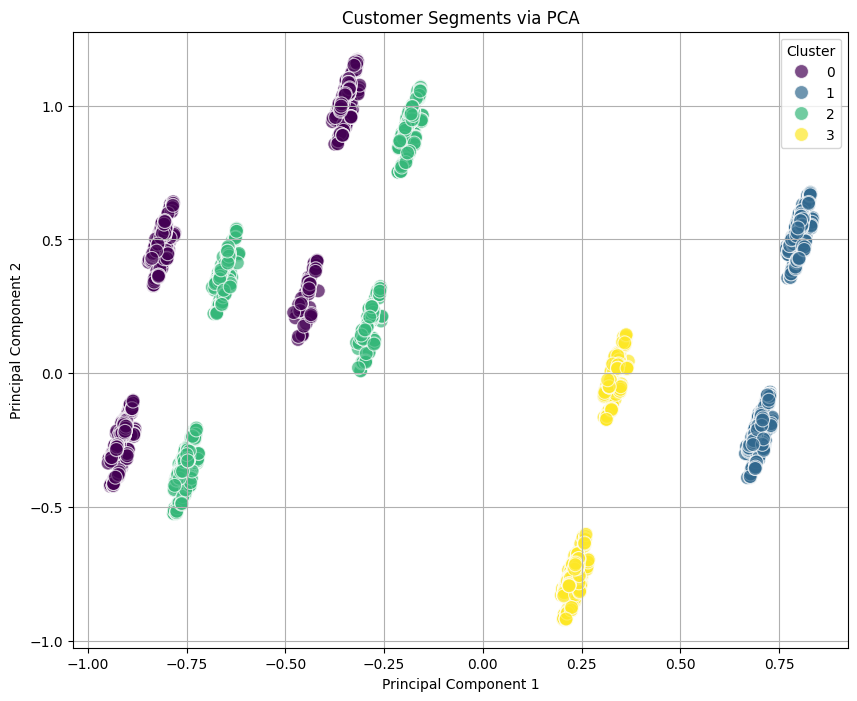

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
X_pca_transformed = pca.fit_transform(X.drop('Cluster', axis=1))

X_pca = pd.DataFrame(data=X_pca_transformed, columns=['PC1', 'PC2'])
X_pca['Cluster'] = X['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=X_pca, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


## Analyze Cluster Characteristics



In [9]:
cluster_means = X.groupby('Cluster').mean()
display(cluster_means)

,SeniorCitizen,tenure,MonthlyCharges,IsNewCustomer,gender,Dependents,PhoneService,MultipleLines,InternetService,Contract_Month-to-month,Contract_One year,Contract_Two year,Churn
Cluster,,,,,,,,,,,,,
0,0.154572,0.451475,0.470557,0.002950,0.517994,0.296755,0.903245,0.515044,0.253097,0.0,0.0,1.0,0.253687
1,0.154605,0.454574,0.458879,0.001880,0.531955,0.312970,0.905075,0.571898,1.000000,1.0,0.0,0.0,0.261748
2,0.180584,0.447565,0.449934,0.000000,0.490835,0.302783,0.893415,0.418194,0.365920,0.0,1.0,0.0,0.257977
3,0.163137,0.443435,0.471535,0.001145,0.470521,0.283343,0.908987,0.151689,0.000000,1.0,0.0,0.0,0.287350


## Prepareing the Data for ANN Modelling




In [10]:
y = X['Churn']
X_data = X.drop('Churn', axis=1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data preparation for ANN complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data preparation for ANN complete.
X_train shape: (5634, 13)
X_test shape: (1409, 13)
y_train shape: (5634,)
y_test shape: (1409,)


## Define ANN Architecture




In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import Precision, Recall, AUC

# Get the number of features from X_train
input_shape = X_train.shape[1]

# Initialize the Sequential model with an explicit Input layer
model = Sequential([
    tf.keras.Input(shape=(input_shape,), name='input_layer'), # Explicit Input layer
    Dense(32, activation='relu', name='hidden_layer_1'),
    Dense(16, activation='relu', name='hidden_layer_2'), # Renamed for clarity, was hidden_layer_1
    Dense(1, activation='sigmoid', name='output_layer')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall(), AUC(name='auc_score')]
)

# Display the model summary
print("ANN Model Summary:")
model.summary()


ANN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

ANN Model training complete.


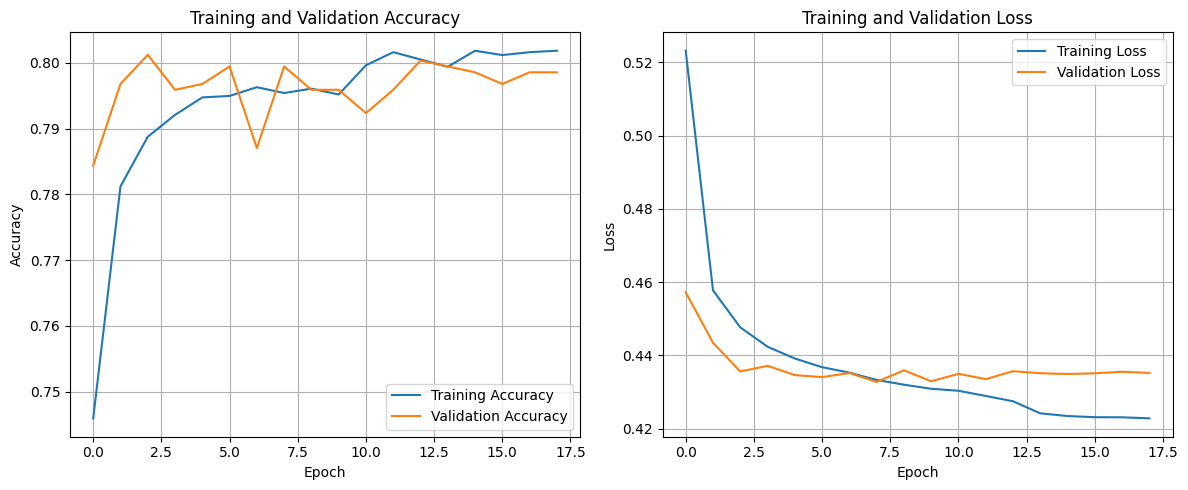

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0 # Suppress verbose output during training
)

print("ANN Model training complete.")

# Plot training history
# Extract data from history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluating ANN Model Performance



In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# 1. Predict churn probabilities on the test set
y_pred_proba = model.predict(X_test)

# 2. Convert probabilities into binary class labels using a threshold of 0.5
y_pred = (y_pred_proba > 0.5).astype(int)

# 3. Calculate and print the overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

# 4. Generate and print a classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# 5. Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Overall Accuracy: 0.7644

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1042
           1       0.56      0.44      0.49       367

    accuracy                           0.76      1409
   macro avg       0.69      0.66      0.67      1409
weighted avg       0.75      0.76      0.75      1409


Confusion Matrix:
[[917 125]
 [207 160]]


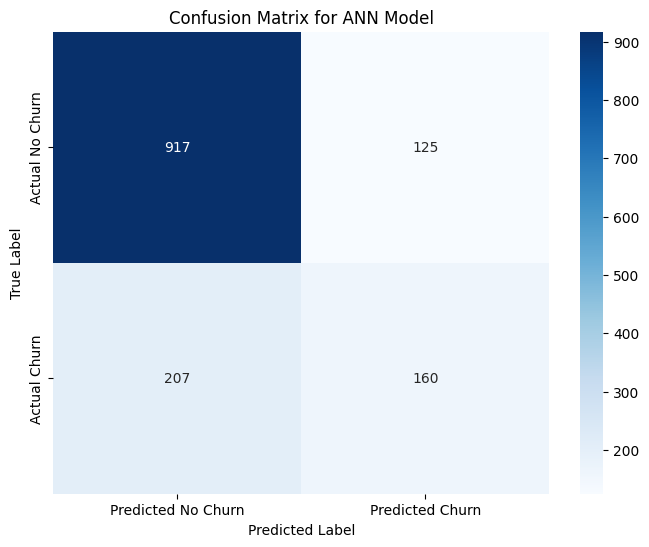

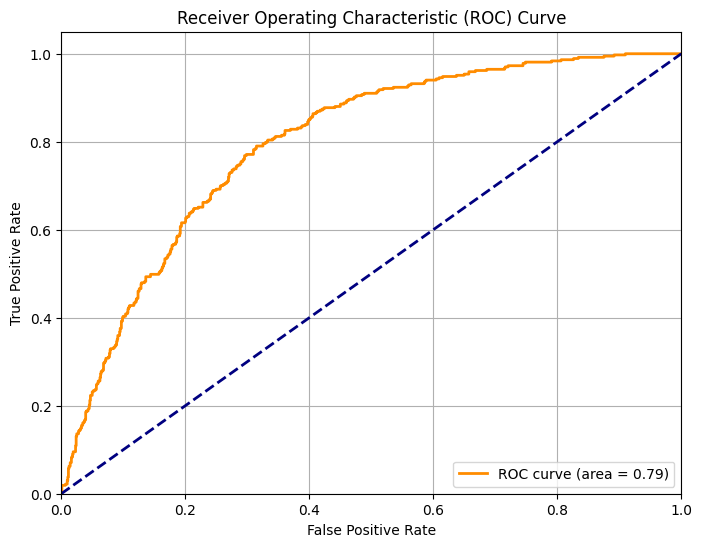

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 6. Visualize the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix for ANN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 7. Calculate FPR, TPR, and AUC score for ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# 8. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Analyze Feature Importance



In [15]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Train a Logistic Regression model on the scaled data
# We use X_data.columns to get the original feature names
# C=0.1 to add some regularization, solver='liblinear' is good for small datasets and L1/L2 regularization
logistic_model = LogisticRegression(solver='liblinear', random_state=42, C=0.1)
logistic_model.fit(X_train, y_train)

# Get feature coefficients
feature_importance = pd.DataFrame({
    'Feature': X_data.columns,
    'Coefficient': logistic_model.coef_[0]
})

# Sort by absolute coefficient value to see most impactful features
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("Top Features by Importance (Logistic Regression Coefficients):")
display(feature_importance.head(10))

print("\nTop Positive Drivers of Churn (features with highest positive coefficients):")
display(feature_importance.sort_values(by='Coefficient', ascending=False).head(5))

print("\nTop Negative Drivers of Churn (features with lowest negative coefficients):")
display(feature_importance.sort_values(by='Coefficient', ascending=True).head(5))

Top Features by Importance (Logistic Regression Coefficients):


,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.341994,1.341994
2,MonthlyCharges,0.976112,0.976112
6,PhoneService,-0.238389,0.238389
0,SeniorCitizen,0.217396,0.217396
3,IsNewCustomer,-0.174253,0.174253
5,Dependents,-0.158603,0.158603
8,InternetService,-0.091937,0.091937
11,Contract_Two year,-0.069775,0.069775
9,Contract_Month-to-month,0.064801,0.064801
12,Cluster,-0.040093,0.040093



Top Positive Drivers of Churn (features with highest positive coefficients):


,Feature,Coefficient,Abs_Coefficient
2,MonthlyCharges,0.976112,0.976112
0,SeniorCitizen,0.217396,0.217396
9,Contract_Month-to-month,0.064801,0.064801
7,MultipleLines,0.035268,0.035268
4,gender,0.015309,0.015309



Top Negative Drivers of Churn (features with lowest negative coefficients):


,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.341994,1.341994
6,PhoneService,-0.238389,0.238389
3,IsNewCustomer,-0.174253,0.174253
5,Dependents,-0.158603,0.158603
8,InternetService,-0.091937,0.091937
